# TD 5: simulation par méthode de Monte Carlo

---

*Une table des quantiles de la loi normale peut par exemple être trouvé ici: https://www.math.arizona.edu/~rsims/ma464/standardnormaltable.pdf*

---

## 1. Calcul de moyenne pour une file d'attente simple


On reprend le modèle de file d'attente simulé au début du cours: la file a une capacité infinie, le taux de service suit une durée aléatoire exponentielle de paramètre 1, et le processus d'arrivée des clients est un processus de Poisson de paramètre $\lambda$. La fonction qui suit simule cette file pour un taux d'arrivé et une durée de simulation donnés, et retourne le nombre moyen de clients mesuré.


In [1]:
import random as rd
import seaborn as sns
import numpy as np
from heapq import heappush, heappop

def duree_exp(p):
    return np.random.exponential(1/p)


def simul_file(lam, t_max):
    """ simule la file d'attente en fonction du taux d'arrivée lam
    et la durée de simulation t_max
    retourne le nombre moyen de clients"""

    # les variables
    t = 0 # temps
    n = 0 # nombre de clients à chaque date
    echeancier = [] # contient les événements à venir
    # On initialise l'échéancier en ajoutant un client
    heappush(echeancier, (0,"client"))
    n_cumul = 0
    # boucle principale
    while t < t_max:
        # on extrait l'événement le plus proche dans le temps
        evt = heappop(echeancier)
        n_cumul += n * (evt[0] - t)
        # on met à jour la date
        t = evt[0]

        # on traite l'événement
        match evt[1]:
            
            case "service":
                # un client part
                n -= 1
                # si il reste un client, il commence son service
                if n > 0:
                    heappush(echeancier, (t + duree_exp(1), "service"))
            case "client":
                # on calcule la date d'arrivée du prochain client
                heappush(echeancier, (t + duree_exp(lam), "client"))
                n += 1
                # si la file était vide, on commence un service
                if n == 1:
                    heappush(echeancier, (t + duree_exp(1), "service"))
                    
    # on retourne les statistiques mesurées 
    return n_cumul / t_max

a. Calculer la moyenne des valeurs obtenues en faisant 100 simulations avec $\lambda = 0.6$ et une durée maximum de simulation de 10000.

b. Calculer la variance des valeurs obtenues avec ce même choix de paramètre, ainsi que l'intervalle de confiance à 95\%.

c. Comparer aux choix de paramètres suivants puis commenter les résultats obtenus.

* 1000 simulations de durée maximum 1000
* 10000 simulations de durée maximum 100
 

In [29]:

def moyenne(data):
    return sum(data) / len(data)

def variance(data):
    m = moyenne(data)
    lst_var = [(e-m)**2 for e in data]
    return sum(lst_var) / (len(data) - 1)

def intervalle_confiance(data):
    m = moyenne(data)
    v = variance(data)
    d = 2.25 * (v / len(data))**0.5
    return m-d, m+d

data = [simul_file(0.6, 100) for _ in range(10000)]

print("moyenne", moyenne(data))
print("variance", variance(data))
print("intervalle de confiance:", intervalle_confiance(data) )



moyenne 1.4502212291709031
variance 0.5575521409226393
intervalle de confiance: (1.4334206109875718, 1.4670218473542345)


---

## 2. Black Jack, version simple à un joueur

Les règles du jeu sont les suivantes:

* initialement, le joueur tire une cartes dans un tas constitué d'un très grand nombre de jeux de 52 cartes mélangés

* les figures valent 10 points, les autres cartes valent leur valeur nominale, excepté l'as qui vaut 11 points

* la valeur d'une main est la somme de la valeur des cartes qui la constitue; si la somme des valeurs dépasse strictement 21, alors la valeur de la main est 0

* à chaque tour, le joueur peut soit s'arrêter auquel cas son score final est la valeur de sa main, ou bien continuer en piochant une nouvelle carte qu'il ajoute à sa main

* si la somme des valeurs des cartes du joueur dépasse strictement 21, le jeu s'arrête et son score est 0


On considère les stratégies $x$ qui consistent à tirer une nouvelle carte tant que la valeur de la main du joueur est inférieure ou égale à $x$ (et non nulle!), et à s'arrêter sinon.

a. En utilisant la simulation de Monte Carlo, déterminer une ou la stratégie qui maximise le score espéré avec une confiance de $95 \%$.

b. Dans la version originale, l'as peut valoir soit 1 soit 11. Est-ce que cela change la stratégie optimale?

In [32]:
def carte():
    """retourne la valeur de la carte tirée"""
    i = rd.randint(2,14)
    if i >= 12:
        return 10
    return i

def score(strat):
    """retourne le score obtenu par la stratégie strat"""
    res = 0
    nb_as = 0
    while True:
        while res > 21 and nb_as > 0:
            res -= 10
            nb_as -= 1
        if res > 21:
            return 0
        if res > strat:
            return res
        c = carte()
        if c == 11:
            nb_as += 1
        res += c

nb_xp = 100000
for strat in range(10,14):
    data = [score(strat) for _ in range(nb_xp)]
    print("stratégie", strat, "moyenne", moyenne(data), "intervalle", intervalle_confiance(data))

    
    

stratégie 10 moyenne 15.38978 intervalle (15.367679080181896, 15.411880919818104)
stratégie 11 moyenne 16.2636 intervalle (16.24312055254706, 16.28407944745294)
stratégie 12 moyenne 16.25162 intervalle (16.223323152021734, 16.279916847978264)
stratégie 13 moyenne 16.09049 intervalle (16.05434851426629, 16.126631485733707)


---

## 3. Réseau pair à pair


On souhaite évaluer la connexité d’un réseau pair à pair formé spontanément
par des connexions aléatoires entre deux utilisateurs (peers), en fonction de
sa taille (nombre d’utilisateurs) et de son degré moyen.  Le réseau
ainsi formé est un graphe $ G = (V, E)$ où $V$ est l’ensemble des sommets de
cardinal $n$, et $E$ l’ensemble des arêtes $(i, j)$ modélisant l’existence
d’une connexion entre les pairs $i$ et $j$. Le cardinal de $E$ est une variable
aléatoire notée $M$.


a. On suppose que le degré moyen du graphe est $d$. Calculer le nombre M
d’arêtes d’un graphe aléatoire à $n$ sommets en fonction de $n$ et de $d$.

b. Écrire un algorithme qui génère uniformément les M arêtes du graphe à $n$
sommets. 

c. Écrire un algorithme qui teste si le graphe est connexe.

d. Etudier en fonction de $d$ et de $n$ la probabilité que le graphe soit
connexe. Pour cela tracer l'estimation de cette probabilité en fonction de d
pour différentes valeurs de $n$. Afficher les intervalles de confiance à $95
\%$.

<Axes: xlabel='degre', ylabel='proba'>

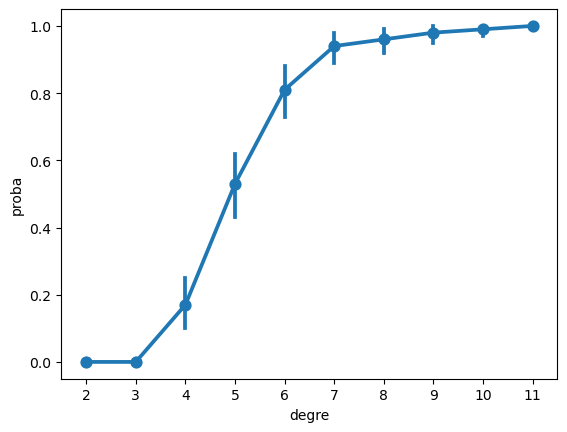

In [60]:
import pandas as pd

def permute_alea(lst):
    """permute la liste aléatoirement"""
    n = len(lst)
    for i in range(n):
        j = rd.randint(i, n-1)
        lst[i], lst[j] = lst[j], lst[i]


def genere_graph(n, d):
    """retourne un graphe aléatoire à n sommets
       et degré moyen d
    """
    # nombre d'arêtes:
    m = (n*d) // 2
    lst_aretes = [(i,j) for i in range(n) for j in range(i+1,n)]
    permute_alea(lst_aretes)
    lst_aretes = lst_aretes[:m]
    # print(lst_aretes)
    adj = [[] for _ in range(n)]
    for (i,j) in lst_aretes:
        adj[i].append(j)
        adj[j].append(i)
    return adj
    
    
def est_connexe_rec(adj, i, marque):
    marque[i] = True
    for v in adj[i]:
        if not marque[v]:
            est_connexe_rec(adj, v, marque)    
    
def est_connexe(adj):
    marque = [False]*len(adj)
    est_connexe_rec(adj, 0, marque)
    return all(marque)

nb_xp = 100
n = 100
y = []
x = []
for d in range(2, 12):
    for _ in range(nb_xp):
        adj = genere_graph(n, d)
        if est_connexe(adj):
            res = 1
        else:
            res = 0
        y += [res]
        x += [d]
    
    

    
table = pd.DataFrame({'degre': x, 'proba': y})
sns.pointplot(data=table, x='degre', y='proba', errorbar='ci')  





---

## 4. Corriger une pièce


On dispose d'une pièce de monnaie biaisée, c'est-à-dire que la fréquence
d'apparition de piles ou de faces n'est pas égale à $\frac 1 2$.

On modélise les lancers de la pièce par des variables aléatoires indépendantes
$X_i$ à valeur dans $\{0,1\}$ et on note

$$ p = \mathbb{P}[X_i =1] $$

Quitte à inverser le rôle de Pile et Face, on supposera que $p < \frac12$.

a. Quelle est la loi du couple $(X_1, X_2)$?

On note $Y_2$ la variable aléatoire à valeurs dans  $\{0,1\}$ définie par $ Y_2 = (X_1 + X_2) \mod 2 $.


b. Quelle est la loi de $Y_2$? 


On note

$$\pi_2 = \mathbb{P}[Y_2 = 1] $$
 
c. Montrer que 

$$\pi_2 - \frac 1 2 = \left( p - \frac 1 2 \right) \left( 1-2p \right) $$



d. Qui de $X_1$ ou de $Y_2$ fournit la meilleure simulation
d'une pièce non biaisée? 


On généralise maintenant le procédé en définissant  

$$Y_n= (X_1 + X_2 + \cdots +X_n) \mod 2$$

et 

$$\pi_n = \mathbb{P}[Y_n = 1] $$

Noter que $Y_n$ est la parité du nombre de Piles en $n$ lancers.


e. Exprimer $\pi_n$ en fonction de $\pi_{n-1}$ et $p$.

f. Calculer   dans ce cas, $\pi_n- \frac 1 2$ en fonction de $p- \frac 1 2$.

g. Application : on suppose  $p=0.4$. Pour quelle valeur minimale de $n$ aura-t-on 

$$ \left| \pi_n- \frac 1 2\right| < 10^{-6} $$








